In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn import set_config

In [33]:
# Set sklearn to automatically convert transformer output to dataframe

set_config(transform_output="pandas")

## Load the data

In [1]:
df = pd.read_csv("./data/laptop_price_merged_categories.csv")
df.head()

NameError: name 'pd' is not defined

## Check data info

In [ ]:
df.info()

## Split the data

In [37]:
num_feats = df.select_dtypes("number").columns.drop("price_euros").to_list()
cat_feats = df.select_dtypes("object").columns.to_list()

X = df.drop("price_euros", axis=1)

NameError: name 'df' is not defined

## Preprocess data

In [38]:
preprocessor = ColumnTransformer(
    [
        ("cat", OneHotEncoder(sparse_output=True, drop="if_binary"), cat_feats),
        ("num", SimpleImputer(), num_feats)
    ],
    verbose_feature_names_out=False,
)
X_processed = preprocessor.fit_transform(X)
X_processed.head()

NameError: name 'cat_feats' is not defined

In [39]:
X_processed_scaled = StandardScaler().fit_transform(X_processed)

NameError: name 'X_processed' is not defined

## Build KMeans Model

In [40]:
inertias = []
sl_scores = []
n_clusters = range(2, 20)

for n_cluster in n_clusters:
    _kmeans = KMeans(n_cluster, random_state=42)
    _kmeans.fit(X_processed_scaled)
    _inertia = _kmeans.inertia_
    _sl_score = silhouette_score(X_processed_scaled, _kmeans.labels_)
    inertias.append(_inertia)
    sl_scores.append(_sl_score)

NameError: name 'X_processed_scaled' is not defined

ValueError: x and y must have same first dimension, but have shapes (18,) and (0,)

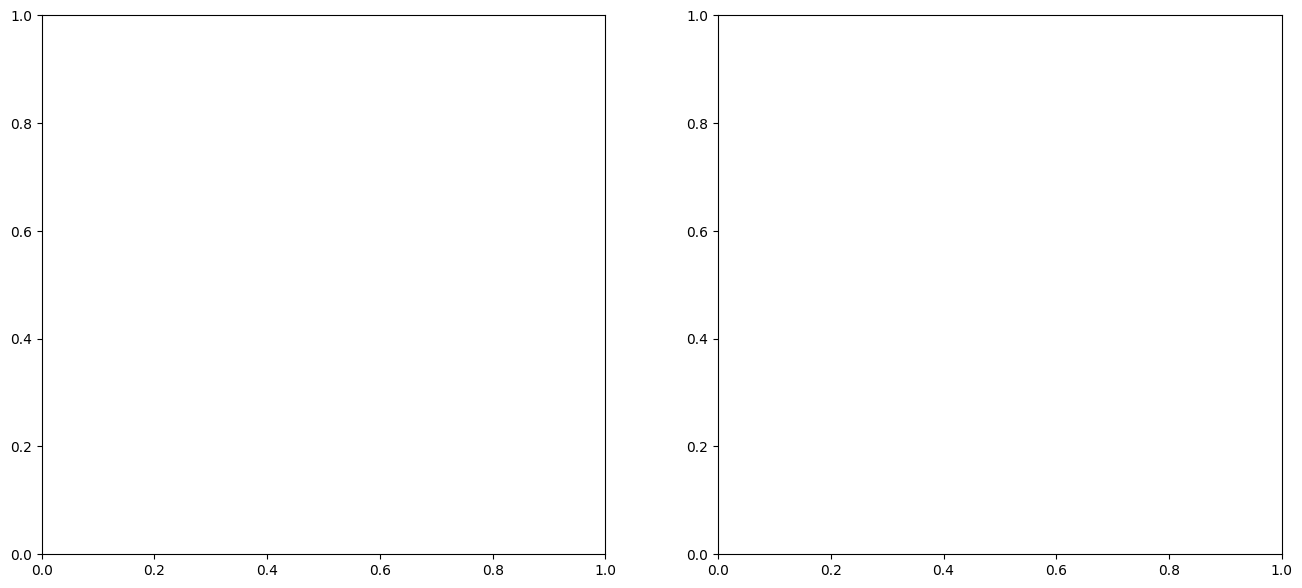

In [41]:
_, ax = plt.subplots(1, 2, figsize=(16, 7))
ax[0].plot(n_clusters, inertias)
ax[1].plot(n_clusters, sl_scores)
ax[0].set_xlabel("N_clusters")
ax[0].set_ylabel("Inertial")
ax[1].set_xlabel("N_clusters")
ax[1].set_ylabel("Silhouette Score")
ax[0].set_xticks(n_clusters)
ax[1].set_xticks(n_clusters)
ax[0].grid()
ax[1].grid();

### Retrain kmeans with 8 clusters

In [ ]:
kmeans = KMeans(n_clusters=8, random_state=42)
kmeans.fit(X_processed_scaled)

In [ ]:
kmeans.inertia_

### Analyze the clusters

In [ ]:
cluster_labels = "cluster_" + (kmeans.labels_ + 1).astype(str)
df_clustered = df.assign(cluster_label = cluster_labels)
# OR
# df_clustered = df.copy()
# df_clustered["cluster_label"] = cluster_labels
df_clustered.head()

### Visualize clusters with PCA

In [ ]:
pca = PCA(2)
pca.fit(X_processed_scaled)

In [ ]:
pca.explained_variance_ratio_

In [ ]:
df_pca = pca.transform(X_processed_scaled)
df_pca.head()

In [ ]:
sns.scatterplot(
    x=df_pca["pca0"], y=df_pca["pca1"], hue=df_clustered["cluster_label"]
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(bbox_to_anchor=[1.15, 1.01])

## Analyze the clusters

In [ ]:
# Number samples in each cluster

ax = df_clustered["cluster_label"].value_counts().plot(kind="bar")
ax.bar_label(ax.containers[0])

plt.title("Number of Samples per Cluster");

### Visualize Average Value of Numeric Columns Per Cluster

In [ ]:
num_plot_cols = ["price_euros"] + num_feats

In [ ]:
for col in num_plot_cols:
    avg_values = df_clustered[col].groupby(df_clustered["cluster_label"]).mean()

    _, ax = plt.subplots(1, 2, figsize=(16, 7))
    bar_plot = sns.barplot(avg_values, ax=ax[0])
    ax[0].bar_label(ax[0].containers[0])
    ax[0].set_title(f"Average {col.title()} Per Cluster")
    ax[0].set_xlabel("Cluster")
    ax[0].set_ylabel(f"Average {col.title()}")

    sns.boxplot(df_clustered, x="cluster_label", y=col, ax=ax[1], order=avg_values.index)
    ax[1].set_title(f"Distribution of {col.title()} Per Cluster")
    ax[1].set_xlabel("Cluster")
    ax[1].set_ylabel(f"{col.title()}")

    plt.show()

### Visualize Proportion of Categorical Columns per Cluster

In [ ]:
cat_feats

In [ ]:
fig, ax = plt.subplots(4, 3, figsize=(16, 16), sharey=False)
ax = ax.ravel()

for ax_idx, col in enumerate(cat_feats):
    pd.crosstab(
        df_clustered["cluster_label"], df_clustered[col], normalize="index"
    ).plot(kind="bar", stacked=True, ax=ax[ax_idx])
    ax[ax_idx].legend(bbox_to_anchor=[1, 1.01])
    ax[ax_idx].set_title(f"Proportion of {col.title()} per Cluster")

# Remove extra axes
fig.delaxes(ax[11])

plt.tight_layout()

In [42]:
plt.savefig("")

<Figure size 640x480 with 0 Axes>

## Key Observations

#### Cluster 1

* Average price: 1263.54 euros
* Average ram: 7.9gb
* Average weight: 1.59kg
* Average primary memory size: 343kg
* Averge secondary memory size: 13.77
* Average cpu speed: 2.27
* Mostly contains HP and Lenovo laptops
* Mostly contains notebooks and ultrabooks
* Mostly 1920x1080 screen resolution
* Uses intel CPU
* Uses intel GPU
* Mostly HD Graphics 620
* Mostly doesn't have secondary memory
* Mostly Core i5

#### Cluster 2

List the obervations in cluster 2

## Plot Correlation Between Cluster Distances and Target

In [43]:
distances = kmeans.transform(X_processed_scaled)

NameError: name 'kmeans' is not defined

In [ ]:
distances.corrwith(df["price_euros"]).sort_values(key=abs).plot(kind="barh")
plt.title("Corrlation Between Cluster Distances and Laptop Price");